# Decision Tree Classification

## Learning Objectives

By the end of this lecture, students should be able to:

1. explain what a **decision tree classifier** is  
2. identify the parts of a tree: **root node, split, branch, leaf**  
3. understand the idea of **Gini impurity**  
4. explain how a tree chooses the **best split**  
5. fit and interpret a simple **decision tree classifier in Python**

---

## What is a Decision Tree?

A **decision tree** is a supervised learning model that makes predictions using a sequence of **if-then questions**.

For **classification**, the target variable is **categorical**.  
Examples:

- Pass / Fail
- Yes / No
- Apple / Orange

A decision tree keeps splitting the data into smaller groups until the groups become as **pure** as possible.


## Important Vocabulary

- **Root node**: the first split at the top of the tree  
- **Internal node**: a later split inside the tree  
- **Branch**: one path after a split  
- **Leaf node**: the final predicted class  

A good split should create groups that are **less mixed** and **more pure**.


## Gini Impurity

A common measure of impurity in a classification tree is the **Gini impurity**:

$$
\text{Gini} = 1 - \sum p_i^2
$$

where $p_i$ is the proportion of class $i$ in the node.

### Interpretation

- **Gini = 0** means the node is perfectly pure  
- larger Gini means the node is more mixed  

The tree tries possible splits and chooses the one with the **smallest weighted Gini impurity**.

> **Note:** Some decision tree implementations use **entropy / information gain** instead of Gini. The idea is the same — measure how mixed a node is — just with a different formula. We will use Gini throughout this lecture.


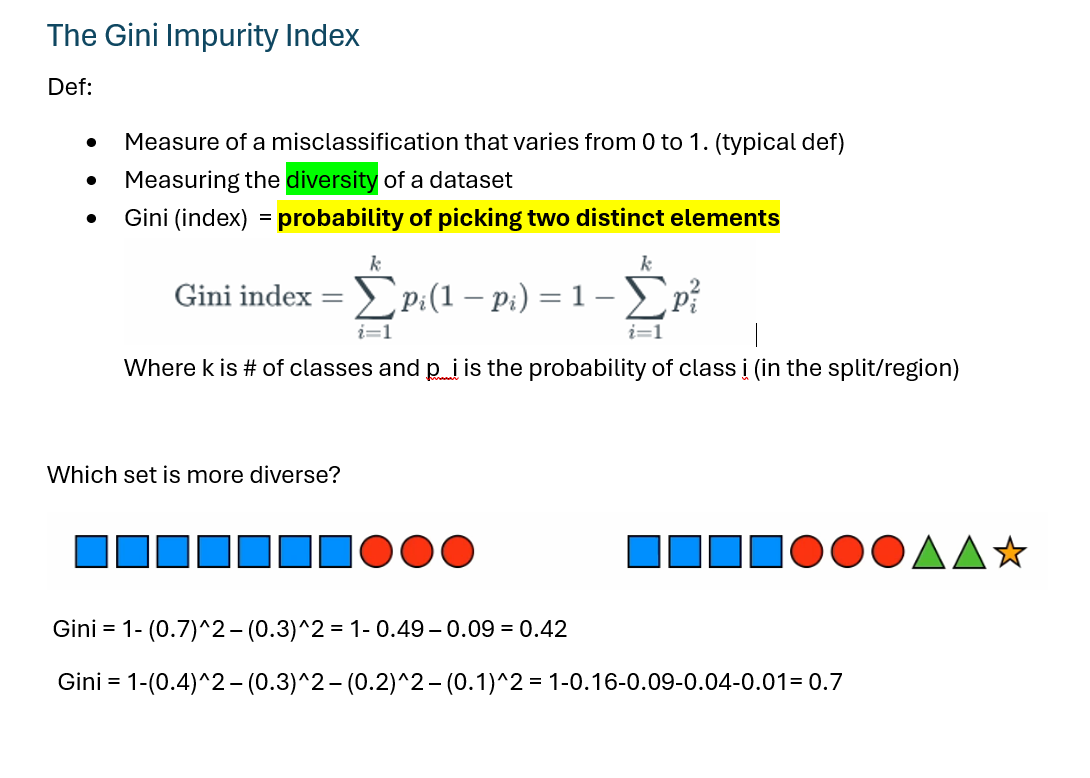

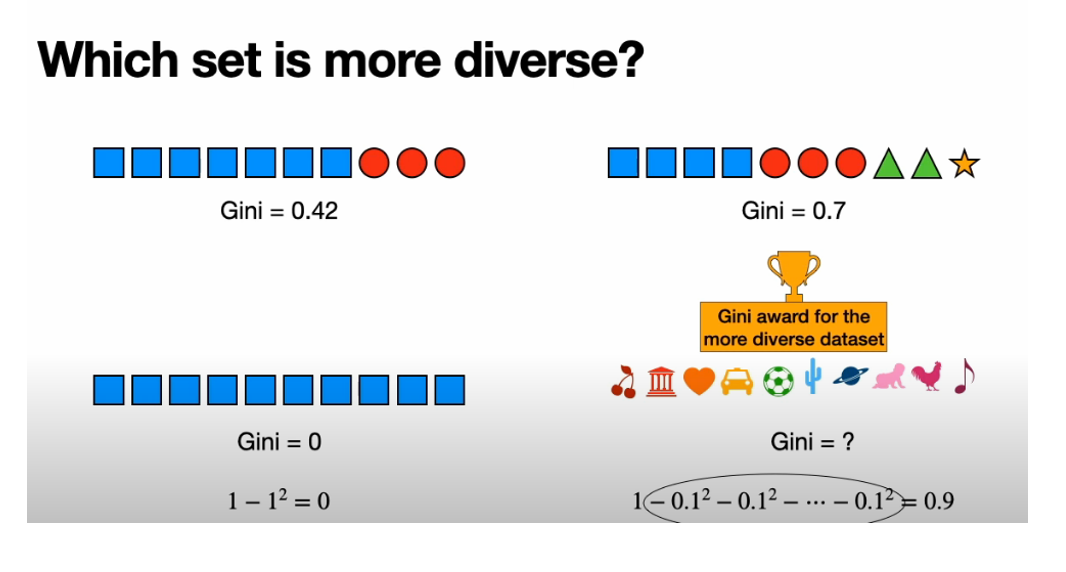

# Example 1: Fruit Example (Hand Calculation)

We will use the following simple dataset of 6 fruits with **numeric** features.

| Weight (g) | Diameter (cm) | Class  |
|------------|---------------|--------|
| 180        | 8.0           | Apple  |
| 170        | 7.5           | Apple  |
| 140        | 7.8           | Apple  |
| 160        | 8.2           | Orange |
| 130        | 7.2           | Orange |
| 120        | 7.6           | Orange |

Features:

- **Weight**
- **Diameter**

Target:

- **Class**

Notice that there is some **overlap**: one of the apples (140 g) is actually lighter than one of the oranges (160 g). So no single split will perfectly separate the classes. That is realistic — real data almost never splits cleanly.

Because the features are numeric, a split now uses a **threshold**, for example "Weight ≤ 135." We will compare two possible first splits:

1. split on **Weight ≤ 135**
2. split on **Diameter ≤ 7.7**


## Step 1: Parent Node

Before splitting, all 6 observations are together.

Class counts:

- Apple = 3
- Orange = 3

So the Gini impurity of the parent node is:

$$
\text{Gini}_{\text{parent}}
=
1-\left[\left(\frac{3}{6}\right)^2+\left(\frac{3}{6}\right)^2\right]
=
0.5
$$

So the starting node is mixed.


## Step 2: Find All Candidate Splits

For a numeric feature, the tree first **sorts the feature values**, then considers the **midpoint between each pair of adjacent values** as a candidate threshold.

### Candidate thresholds for Weight

Sorted weights (smallest to largest):

| Weight | 120    | 130    | 140    | 160    | 170    | 180    |
|--------|--------|--------|--------|--------|--------|--------|
| Class  | Orange | Orange | Apple  | Orange | Apple  | Apple  |

Midpoints between adjacent values:

- midpoint of 120 and 130 → **125**
- midpoint of 130 and 140 → **135**
- midpoint of 140 and 160 → **150**
- midpoint of 160 and 170 → **165**
- midpoint of 170 and 180 → **175**

This gives **5 candidate thresholds** for Weight.

### Candidate thresholds for Diameter

Sorted diameters:

| Diameter | 7.2    | 7.5   | 7.6    | 7.8   | 8.0   | 8.2    |
|----------|--------|-------|--------|-------|-------|--------|
| Class    | Orange | Apple | Orange | Apple | Apple | Orange |

Midpoints between adjacent values give the candidate thresholds:
**7.35, 7.55, 7.70, 7.90, 8.10** → another **5 candidates**.

### Ten candidates in total

So at the root, the tree has **10 candidate splits** to evaluate:

| Feature  | Candidate thresholds              |
|----------|-----------------------------------|
| Weight   | 125, 135, 150, 165, 175           |
| Diameter | 7.35, 7.55, 7.70, 7.90, 8.10      |

**Important:** Weight and Diameter do **not** take turns. The tree pools all 10 candidates into one list, computes the weighted Gini for each, and picks the single best — regardless of which feature it comes from.

> **Implementation note:** Internally, `DecisionTreeClassifier` loops through features one at a time in code — but since the final choice is the overall best (feature, threshold) pair, the outcome is the same as if all 10 were compared simultaneously.


## Step 3: Compute the Weighted Gini for All 10 Candidates

Here is the weighted Gini impurity for every candidate split:

| Feature   | Threshold | Left (A, O) | Right (A, O) | Weighted Gini |
|-----------|-----------|-------------|--------------|---------------|
| Weight    | 125       | (0, 1)      | (3, 2)       | 0.400         |
| Weight    | **135**   | (0, 2)      | (3, 1)       | **0.250** ✓   |
| Weight    | 150       | (1, 2)      | (2, 1)       | 0.444         |
| Weight    | **165**   | (1, 3)      | (2, 0)       | **0.250** ✓   |
| Weight    | 175       | (2, 3)      | (1, 0)       | 0.400         |
| Diameter  | 7.35      | (0, 1)      | (3, 2)       | 0.400         |
| Diameter  | 7.55      | (1, 1)      | (2, 2)       | 0.500         |
| Diameter  | 7.70      | (1, 2)      | (2, 1)       | 0.444         |
| Diameter  | 7.90      | (2, 2)      | (1, 1)       | 0.500         |
| Diameter  | 8.10      | (3, 2)      | (0, 1)       | 0.400         |

The smallest weighted Gini is **0.25**, achieved by two splits:

- **Weight ≤ 135**
- **Weight ≤ 165**

When there is a tie, implementations such as `DecisionTreeClassifier` break it using a fixed rule (for example, the first one found). In this lecture we will use **Weight ≤ 135**.

Notice also that **every Diameter split has Gini ≥ 0.4**, while Weight offers two splits at 0.25. This is why the tree prefers Weight over Diameter as the root split.


## Step 4: Two Detailed Gini Calculations (Educational)

The table above shows the final numbers. Now let's see where two of those numbers actually come from. We'll walk through **Weight ≤ 135** (the winner) and **Diameter ≤ 7.7** (for contrast).

### Example A: Weight ≤ 135 (weighted Gini = 0.25)

**Left node — Weight ≤ 135:** 130 (Orange), 120 (Orange) → 0 Apples, 2 Oranges

This node is pure:

$$
\text{Gini}_{\text{left}} = 0
$$

**Right node — Weight > 135:** 140 (Apple), 160 (Orange), 170 (Apple), 180 (Apple) → 3 Apples, 1 Orange

$$
\text{Gini}_{\text{right}}
=
1-\left[\left(\frac{3}{4}\right)^2+\left(\frac{1}{4}\right)^2\right]
=
1-\frac{9}{16}-\frac{1}{16}
=
\frac{6}{16}
=
0.375
$$

**Weighted Gini:**

$$
\text{Weighted Gini}
=
\frac{2}{6}(0)+\frac{4}{6}(0.375)
=
0.25
$$

### Example B: Diameter ≤ 7.7 (weighted Gini = 0.444)

**Left node — Diameter ≤ 7.7:** 170/7.5 (Apple), 130/7.2 (Orange), 120/7.6 (Orange) → 1 Apple, 2 Oranges

$$
\text{Gini}_{\text{left}}
=
1-\left[\left(\frac{1}{3}\right)^2+\left(\frac{2}{3}\right)^2\right]
=
\frac{4}{9}\approx 0.444
$$

**Right node — Diameter > 7.7:** 180/8.0 (Apple), 140/7.8 (Apple), 160/8.2 (Orange) → 2 Apples, 1 Orange

$$
\text{Gini}_{\text{right}}
=
1-\left[\left(\frac{2}{3}\right)^2+\left(\frac{1}{3}\right)^2\right]
=
\frac{4}{9}\approx 0.444
$$

**Weighted Gini:**

$$
\text{Weighted Gini}
=
\frac{3}{6}(0.444)+\frac{3}{6}(0.444)\approx 0.444
$$

You can verify any other row in the Step 3 table the same way: count Apples and Oranges on each side, compute the Gini for each node, then take the weighted average.


## Step 5: The Resulting Decision Tree

Here is the tree we just built by hand, using the winning split **Weight ≤ 135**:

<svg viewBox="0 0 700 400" xmlns="http://www.w3.org/2000/svg" style="font-family: Helvetica, Arial, sans-serif; max-width: 700px;">
  <text x="350" y="28" text-anchor="middle" font-size="17" font-weight="bold" fill="#1f2937">Fruit Example — Learned Decision Tree</text>
  <rect x="265" y="60" width="170" height="85" rx="10" fill="#f3f4f6" stroke="#4b5563" stroke-width="2"/>
  <text x="350" y="85" text-anchor="middle" font-size="15" font-weight="bold" fill="#111827">Weight ≤ 135 g ?</text>
  <text x="350" y="107" text-anchor="middle" font-size="12" fill="#374151">Gini = 0.500</text>
  <text x="350" y="126" text-anchor="middle" font-size="12" fill="#374151">3 Apples · 3 Oranges</text>
  <text x="455" y="75" font-size="11" fill="#6b7280" font-style="italic">← root node</text>
  <line x1="310" y1="145" x2="185" y2="255" stroke="#4b5563" stroke-width="2"/>
  <line x1="390" y1="145" x2="515" y2="255" stroke="#4b5563" stroke-width="2"/>
  <rect x="218" y="185" width="40" height="22" rx="4" fill="#ffffff" stroke="#4b5563" stroke-width="1"/>
  <text x="238" y="201" text-anchor="middle" font-size="12" font-weight="bold" fill="#059669">Yes</text>
  <rect x="442" y="185" width="40" height="22" rx="4" fill="#ffffff" stroke="#4b5563" stroke-width="1"/>
  <text x="462" y="201" text-anchor="middle" font-size="12" font-weight="bold" fill="#b91c1c">No</text>
  <rect x="100" y="255" width="170" height="85" rx="10" fill="#fed7aa" stroke="#c2410c" stroke-width="2"/>
  <text x="185" y="280" text-anchor="middle" font-size="15" font-weight="bold" fill="#7c2d12">Predict: Orange</text>
  <text x="185" y="302" text-anchor="middle" font-size="12" fill="#7c2d12">Gini = 0 (pure)</text>
  <text x="185" y="321" text-anchor="middle" font-size="12" fill="#7c2d12">0 Apples · 2 Oranges</text>
  <rect x="430" y="255" width="170" height="85" rx="10" fill="#fecaca" stroke="#b91c1c" stroke-width="2"/>
  <text x="515" y="280" text-anchor="middle" font-size="15" font-weight="bold" fill="#7f1d1d">Predict: Apple</text>
  <text x="515" y="302" text-anchor="middle" font-size="12" fill="#7f1d1d">Gini = 0.375</text>
  <text x="515" y="321" text-anchor="middle" font-size="12" fill="#7f1d1d">3 Apples · 1 Orange</text>
  <text x="185" y="362" text-anchor="middle" font-size="11" fill="#6b7280" font-style="italic">leaf node</text>
  <text x="515" y="362" text-anchor="middle" font-size="11" fill="#6b7280" font-style="italic">leaf node</text>
</svg>

### Reading the tree

- Ask the root question: **is Weight ≤ 135 g?**
- If **Yes**, follow the left branch → predict **Orange**
- If **No**, follow the right branch → predict **Apple**

The right leaf is not perfectly pure: the 160 g orange ends up on the "Apple" side and would be misclassified by this simple tree. In practice, the tree could split this node again (for example, on Diameter) to clean it up. For now, we stop after one split to focus on the main idea: **how the tree chooses which feature and threshold to use**.


## Key Idea from the Fruit Example

A decision tree does this at every node:

1. try possible splits (for numeric features, candidate thresholds between sorted values)  
2. compute the weighted Gini impurity after each split  
3. choose the split with the **smallest weighted Gini impurity**

That is how the tree grows.


# Example 2: Python Code Example

Now we will fit a **decision tree classifier in Python** using a small dataset typed directly into the notebook.

In this example:

- the features are numeric
- the target is categorical: **Pass** or **Fail**
- the goal is to see how to build, train, and visualize a decision tree


In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Create the dataset directly in the notebook
# Result = Pass or Fail

student_df = pd.DataFrame({
    "StudyHours":    [2, 3, 3, 4, 4, 5, 3, 4, 5, 3,
                      7, 8, 9, 8, 7, 9, 8, 7, 9, 8,
                      6, 6, 7, 5, 6,
                      5, 5, 6, 4, 5,
                      6, 7, 5, 6, 7, 5, 6, 7, 6, 5],
    "Attendance":    [60, 65, 70, 68, 62, 75, 67, 71, 64, 60,
                      85, 88, 90, 86, 87, 92, 89, 84, 91, 88,
                      78, 82, 75, 80, 79,
                      82, 78, 85, 80, 81,
                      72, 76, 70, 78, 74, 73, 77, 71, 75, 79],
    "PracticeScore": [45, 50, 55, 52, 48, 60, 53, 58, 50, 47,
                      80, 85, 88, 82, 84, 90, 86, 81, 89, 87,
                      72, 75, 70, 73, 71,
                      68, 65, 72, 63, 70,
                      62, 78, 60, 75, 80, 65, 76, 72, 70, 68],
    "Result":        ["Fail", "Fail", "Fail", "Fail", "Fail", "Fail", "Fail", "Fail", "Fail", "Fail",
                      "Pass", "Pass", "Pass", "Pass", "Pass", "Pass", "Pass", "Pass", "Pass", "Pass",
                      "Fail", "Fail", "Fail", "Fail", "Fail",
                      "Pass", "Pass", "Pass", "Pass", "Pass",
                      "Fail", "Pass", "Fail", "Pass", "Pass", "Fail", "Pass", "Fail", "Pass", "Fail"]
})

student_df

,StudyHours,Attendance,PracticeScore,Result
0,2,60,45,Fail
1,3,65,50,Fail
2,3,70,55,Fail
3,4,68,52,Fail
4,4,62,48,Fail
5,5,75,60,Fail
6,3,67,53,Fail
7,4,71,58,Fail
8,5,64,50,Fail
9,3,60,47,Fail


The dataset has **40 students** with three numeric features. Some students have feature values that don't cleanly match their final outcome — for example, a student with decent study hours who still failed, or a student with modest study hours who still passed. This kind of overlap is realistic, and it means our tree will not be able to predict every student perfectly.


In [3]:
# Define X (input features) and y (target variable)
X = student_df[["StudyHours", "Attendance", "PracticeScore"]]
y = student_df["Result"]

In [4]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

In [5]:
# Create the decision tree classifier
tree_clf = DecisionTreeClassifier(
    criterion="gini",   # Use Gini impurity
    max_depth=3,        # Keep the tree simple
    random_state=1
)

# Train the model
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=1)

In [6]:
# Make predictions on the test set
y_pred = tree_clf.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=["Fail", "Pass"]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8

Confusion Matrix:
[[4 1]
 [1 4]]

Classification Report:
              precision    recall  f1-score   support

        Fail       0.80      0.80      0.80         5
        Pass       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10



> **Note:** With 40 rows and a 25% test split, the test set has 10 observations, so accuracy moves in steps of 10%. The dataset is still small for a real-world evaluation, but it is large enough to give a more informative confusion matrix.

### Reading the confusion matrix

With labels ordered `[Fail, Pass]`, the confusion matrix has this layout:

|                    | Predicted Fail      | Predicted Pass      |
|--------------------|---------------------|---------------------|
| **Actual Fail**    | True Negative (TN)  | False Positive (FP) |
| **Actual Pass**    | False Negative (FN) | True Positive (TP)  |

where "Pass" is treated as the positive class.

- **False Positive (FP):** the student actually failed, but the model predicted Pass.
- **False Negative (FN):** the student actually passed, but the model predicted Fail.

Both kinds of errors appear in our confusion matrix, which is what we should expect: the data has overlap, and a depth-3 tree cannot separate all 40 students perfectly.


## Show the Learned Rules

The tree learns a sequence of if-then rules from the data.


In [ ]:
# Print the rules learned by the tree
print(export_text(tree_clf, feature_names=list(X.columns)))

## Visualize the Tree

This picture helps us see:

- which variable is used first
- which thresholds are used
- which class is predicted at each leaf


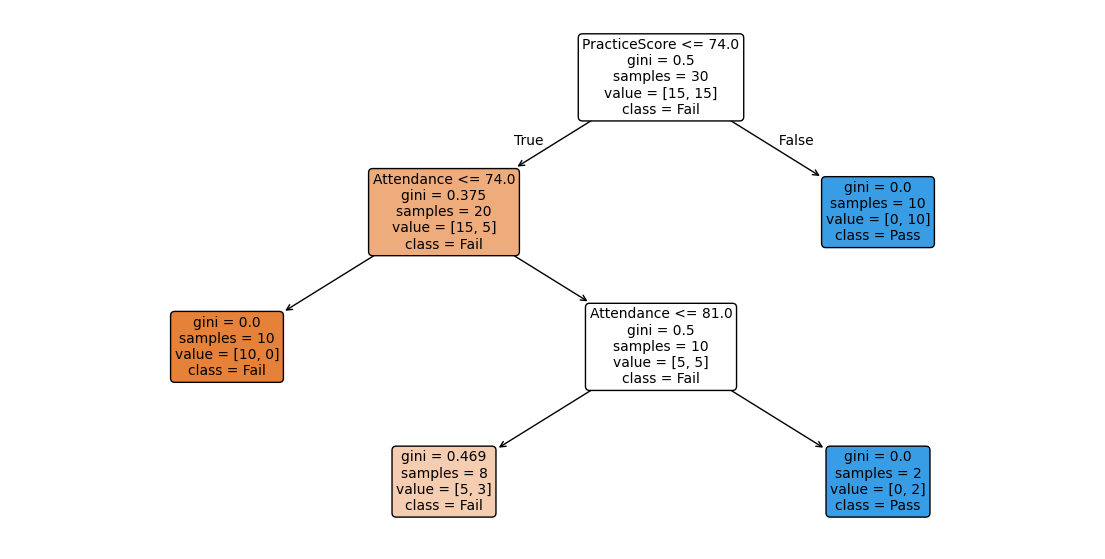

In [7]:
# Plot the decision tree
plt.figure(figsize=(14, 7))

plot_tree(
    tree_clf,
    feature_names=X.columns,
    class_names=tree_clf.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

## Reading the Tree Diagram

Each box in the diagram is a node and shows four pieces of information:

- **the split rule** (only on internal nodes), e.g. `PracticeScore ≤ 74.0`
- **gini** — the Gini impurity computed from this node's class distribution
- **samples** — the number of training students that reached this node
- **value** — the count in each class
- **class** — the prediction the tree would make if it stopped here (the majority class in the node)

### Which number in `value` is Fail and which is Pass?

The order of the numbers in `value` matches the order of `tree_clf.classes_`. When you train a sklearn classifier, it sorts the unique class labels **alphabetically** and stores them in this attribute. For us, `'Fail' < 'Pass'` alphabetically, so:

```
tree_clf.classes_ = ['Fail', 'Pass']
```

This means in every node:

- `value[0]` is the **Fail** count (always the first number)
- `value[1]` is the **Pass** count (always the second number)

So `value = [15, 5]` means **15 Fails and 5 Passes**, not the other way around. You can always double-check by printing `tree_clf.classes_`.

### Walking through the first three nodes

Let's read the **first three nodes** of our trained tree.

#### Root node

- split rule: **PracticeScore ≤ 74.0**
- gini = **0.5**
- samples = **30**
- value = **[15, 15]** → 15 Fails, 15 Passes
- class = **Fail**

This is the very top of the tree, before any splitting has happened. All 30 training students are here. The class counts are exactly balanced, so the Gini impurity reaches its maximum value:

$$
\text{Gini} = 1 - \left(\frac{15}{30}\right)^2 - \left(\frac{15}{30}\right)^2 = 0.5
$$

The `class` label is **Fail** simply because Fail comes first alphabetically; this is sklearn's default rule for breaking ties. The split rule says: send everyone with PracticeScore ≤ 74 to the left child, and everyone with PracticeScore > 74 to the right child.

#### Left child (when PracticeScore ≤ 74 is **True**)

- split rule: **Attendance ≤ 74.0**
- gini = **0.375**
- samples = **20**
- value = **[15, 5]** → 15 Fails, 5 Passes
- class = **Fail**

Of the 30 training students, 20 have PracticeScore ≤ 74, so they end up here. Among those 20, there are 15 Fails and 5 Passes — much less mixed than the parent. The Gini value is computed from this node's distribution:

$$
\text{Gini} = 1 - \left(\frac{15}{20}\right)^2 - \left(\frac{5}{20}\right)^2 = 1 - 0.5625 - 0.0625 = 0.375
$$

Gini dropped from 0.5 to 0.375, confirming that the split improved purity. If we stopped here, the predicted class would be **Fail** (the majority). Since gini is not yet zero, the tree keeps going and tries another split, this time on Attendance.

#### Right child (when PracticeScore ≤ 74 is **False**)

- gini = **0.0**
- samples = **10**
- value = **[0, 10]** → 0 Fails, 10 Passes
- class = **Pass**

The other 10 training students have PracticeScore > 74, and **all 10 are Passes**. There are no Fails here, so the node is perfectly pure:

$$
\text{Gini} = 1 - \left(\frac{0}{10}\right)^2 - \left(\frac{10}{10}\right)^2 = 0
$$

Once a node is pure, there is nothing more to gain from splitting it, so this becomes a **leaf node**. Any future student who reaches this leaf will be predicted as **Pass**.

The remaining nodes in the diagram follow the same logic. You are encouraged to read them on your own using these same four pieces of information.


# Prediction

Once the tree is trained, we can use it to make predictions. There are two situations where we typically do this:

1. **On the test set**, to compare predicted vs. actual outcomes and see where the model went right or wrong.
2. **On new, unseen data**, to use the model for its actual purpose — making decisions about students we have not seen before.

We will look at both situations below.

## Part 1: Inspect Predictions on the Test Set

We already computed predictions for the test set when we evaluated the model. Now let's place them next to the actual outcomes so we can see, row by row, which test students were classified correctly and which were not.


In [ ]:
# Add predictions to the test data for inspection
test_result_df = X_test.copy()
test_result_df["Actual_Result"] = y_test
test_result_df["Predicted_Result"] = y_pred

test_result_df

Rows where `Actual_Result` and `Predicted_Result` differ are the model's mistakes — these correspond to the off-diagonal entries (FP and FN) in the confusion matrix above.

## Part 2: Predict for New, Unseen Students

The real purpose of training a model is to use it on **new data** — students we have never seen before. Suppose two new students show up, and we want the tree to predict whether each will Pass or Fail:

| Student | StudyHours | Attendance | PracticeScore |
|---------|------------|------------|---------------|
| Student A | 7        | 76         | 75            |
| Student B | 8        | 68         | 84            |

Neither student appears anywhere in our original 40-row dataset. The tree was never told what their result is — it has to **predict** it from the rules it learned during training.

### How the tree will decide

We can read the prediction directly from the learned rules (printed earlier with `export_text`). For each new student, we follow the if-then path from the root down to a leaf:

- **Student A** (PracticeScore = 75): the root question is whether PracticeScore is at most 74. Since 75 > 74, we follow the right branch, which is a leaf that predicts **Pass**.
- **Student B** (PracticeScore = 84): same reasoning — 84 > 74, so we again follow the right branch and predict **Pass**.

The code below feeds both students to the trained model and records the predictions in a new column.


In [ ]:
# Predict new, unseen students
new_students = pd.DataFrame({
    "StudyHours": [7, 8],
    "Attendance": [76, 68],
    "PracticeScore": [75, 84]
})

new_students["Predicted_Result"] = tree_clf.predict(new_students)

new_students

## Short Discussion

### Why is this a classification problem?

Because the target variable, **Result**, has categories:

- Pass
- Fail

### Why do we use `max_depth=3`?

A very deep tree can become too complex and may **overfit** the training data — meaning it memorizes the training examples but performs poorly on new data. Using a small `max_depth` helps keep the tree simpler and easier to interpret.

### Important note

In this lecture, our main goal is to understand:

- how the tree chooses splits
- how to fit a classification tree in Python
- how to interpret the resulting rules


# Summary

### Main ideas from today's lecture

1. A **decision tree classifier** predicts categories using if-then rules  
2. At each node, the tree tries possible splits and chooses the one with the **smallest weighted Gini impurity**  
3. In the fruit example, splitting on **Weight** (Gini = 0.25) was better than splitting on **Diameter** (Gini ≈ 0.444)  
4. For numeric features, the tree picks thresholds at midpoints between sorted values  
5. In Python, we can train a tree using `DecisionTreeClassifier`  
6. We can inspect the learned rules using `export_text()` and `plot_tree()`

---

## Optional In-Class Questions

1. What does it mean for a node to be **pure**?  
2. Why was **Weight** better than **Diameter** in the fruit example?  
3. What is the target variable in the Python example?  
4. Why might a very deep decision tree be a problem?


## Answers to In-Class Questions

**1. What does it mean for a node to be pure?**

A pure node is one in which all observations belong to the same class. Its Gini impurity is exactly 0, since one class has proportion 1 and the others have proportion 0. Once a node is pure, no further split could possibly improve it, so the tree turns it into a leaf and stops. In our trained tree, the right child of the root is a pure node — it contains 10 Passes and 0 Fails.

**2. Why was Weight better than Diameter in the fruit example?**

Among the 10 candidate splits we considered, the best Weight split (Weight ≤ 135) produced a weighted Gini of **0.25**, while the best Diameter split only reached about **0.4**. In other words, Weight separated apples from oranges much more cleanly — one of the resulting child nodes was even perfectly pure (Gini = 0). The diameters of apples and oranges overlapped too much for any single threshold to separate them well, so every Diameter split left both child nodes mixed.

**3. What is the target variable in the Python example?**

The target variable is `Result`, with two categories: **Pass** and **Fail**. Because the target is categorical (not numeric), this is a classification problem. The three numeric columns — `StudyHours`, `Attendance`, and `PracticeScore` — are the features the tree uses to predict `Result`.

**4. Why might a very deep decision tree be a problem?**

A very deep tree can keep splitting until each leaf contains only one or two training observations. At that point, the tree has effectively memorized the training data, including its random noise and quirks. Such a tree will achieve very high training accuracy but perform poorly on new, unseen data — this is called **overfitting**. Limiting the depth (with `max_depth`) or the minimum number of samples per leaf keeps the tree simpler, more general, and easier to interpret. In our Python example we used `max_depth=3` for exactly this reason.
